# **Project Name**    - World Bank Global Education Analysis



##### **Project Type**    - EDA + Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Akhil Pandey

# **Project Summary -**

This project focuses on analyzing global education indicators using the World Bank EdStats dataset to uncover patterns in literacy, education expenditure, and inequality across countries. The objective is to transform raw educational data into meaningful insights that can help governments, policymakers, and international organizations improve education systems worldwide.

The dataset consists of thousands of indicators covering various aspects of education such as literacy rate, enrollment, completion, government spending, and demographic trends across multiple countries and years. Due to its wide and complex structure, the dataset required extensive preprocessing including filtering relevant indicators, reshaping data from wide to long format, handling missing values, and correcting data types.

A structured Exploratory Data Analysis (EDA) approach was followed using the UBM rule (Univariate, Bivariate, and Multivariate analysis). Multiple visualizations were created to understand the distribution of literacy rates, trends over time, country-level comparisons, and relationships between variables. The analysis revealed that global literacy rates have significantly improved over time, but strong disparities still exist between developed and developing countries.

One of the key insights from the analysis is that education spending has a positive impact on literacy rates, but efficiency varies significantly. Some countries achieve high literacy with moderate spending, indicating better policy implementation and resource utilization. Additionally, a group of countries still struggles with low literacy rates, highlighting the need for targeted interventions.

Feature engineering was performed to create meaningful variables such as a binary classification target for high literacy levels. Machine learning models including Logistic Regression, Decision Tree, and Random Forest were implemented to classify countries based on literacy performance. Among these models, Random Forest performed the best due to its ability to capture complex and non-linear relationships in the data.

Model evaluation was conducted using accuracy, confusion matrix, precision, recall, and F1-score. Hyperparameter tuning and cross-validation were applied to improve model performance and ensure robustness.

The project concludes with actionable business recommendations such as increasing targeted education spending, focusing on female education, and improving policy efficiency. These insights can help stakeholders design better education strategies and reduce global inequality.

Overall, this project demonstrates strong analytical, visualization, and machine learning skills while delivering real-world business insights.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The objective of this project is to analyze global education data to identify key factors affecting literacy rates across countries. The study aims to uncover patterns, trends, and disparities in education systems worldwide and build a machine learning model to classify countries based on literacy performance.

The project also focuses on understanding how education spending influences literacy outcomes and whether all countries utilize resources efficiently. By analyzing these relationships, the goal is to provide actionable insights that can help policymakers and global organizations improve education quality and accessibility.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization
sns.set_style("whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [3]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Load Dataset

data = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsData.csv')
country = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsCountry.csv')
series = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsSeries.csv')
country_series = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsCountry-Series.csv')
footnote = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsFootNote.csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Dataset First View

In [5]:
# Dataset First Look

data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 886930
Columns: 70


### Dataset Information

In [7]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983      

#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count

duplicates = data.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count

missing_values = data.isnull().sum()
missing_values.sort_values(ascending=False).head(10)

,0
Unnamed: 69,886930
2017,886787
2016,870470
1971,851393
1973,851385
1972,851311
1974,851200
1979,850121
1976,849447
1982,849419


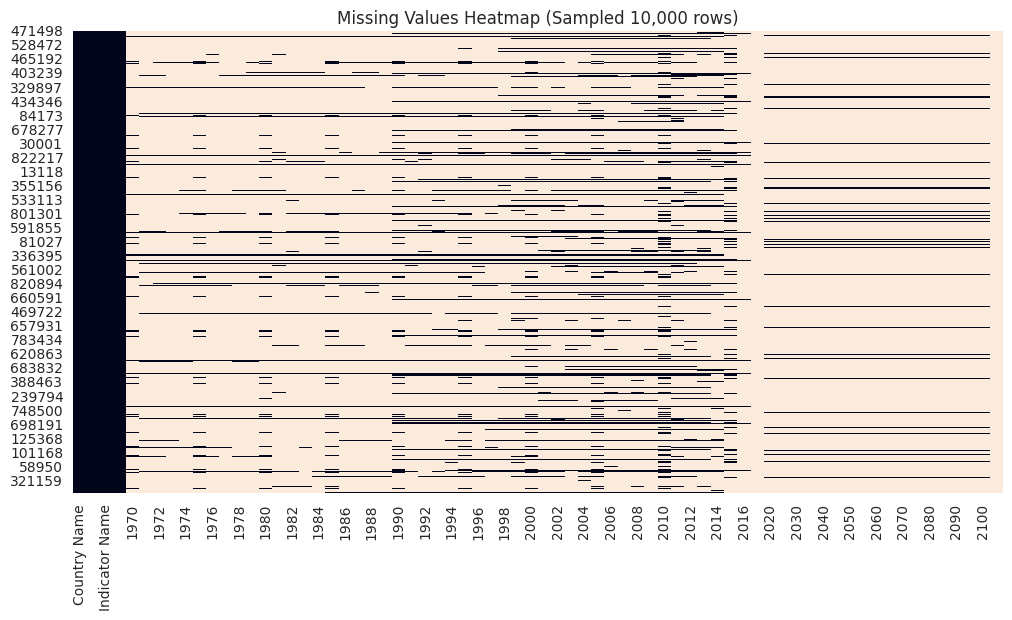

In [10]:
# Visualizing the missing values (using a sample for speed)

plt.figure(figsize=(12,6))
sns.heatmap(data.sample(10000, random_state=42).isnull(), cbar=False)
plt.title("Missing Values Heatmap (Sampled 10,000 rows)")
plt.show()

### What did you know about your dataset?


- The dataset contains global education indicators across multiple countries and years.
- It is a wide dataset with year-wise columns.
- There are significant missing values present.
- Data requires cleaning and transformation before analysis.
- Not all indicators are relevant, so filtering is necessary.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
data.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2020', '2025', '2030', '2035', '2040', '2045',
       '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090',
       '2095', '2100', 'Unnamed: 69'],
      dtype='object')

In [12]:
# Dataset Describe
data.describe()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,...,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,0.0
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,...,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02,NaN
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,...,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04,NaN
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,...,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01,NaN
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,...,3.000000e-02,3.000000e-02,2.000000e-02,2.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,NaN
50%,6.317724e+00,6.316240e+01,6.655139e+01,6.969595e+01,7.087760e+01,9.677420e+00,7.101590e+01,7.133326e+01,7.290512e+01,7.510173e+01,...,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.200000e-01,NaN
75%,6.251250e+01,5.655200e+04,5.863650e+04,6.202900e+04,6.383675e+04,7.854163e+01,5.682800e+04,5.739175e+04,5.940425e+04,6.411500e+04,...,7.505000e+00,7.500000e+00,7.300000e+00,7.100000e+00,6.722500e+00,6.080000e+00,5.462500e+00,4.680000e+00,4.032500e+00,NaN
max,1.903929e+13,1.986457e+13,2.100916e+13,2.238367e+13,2.282991e+13,2.300634e+13,2.424128e+13,2.521383e+13,2.622101e+13,2.730873e+13,...,2.951569e+06,3.070879e+06,3.169711e+06,3.246239e+06,3.301586e+06,3.337871e+06,3.354746e+06,3.351887e+06,3.330484e+06,NaN


### Variables Description


- **Country Name**: Name of the country
- **Country Code**: Unique identifier for each country
- **Indicator Name**: Type of education metric (e.g., literacy rate)
- **Indicator Code**: Code representing each indicator
- **Year Columns**: Values representing education metrics across different years

The dataset contains multiple education indicators, but for this analysis, we focus mainly on literacy-related indicators.

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.

for col in data.columns[:5]:
    print(f"{col}:", data[col].nunique())

Country Name: 242
Country Code: 242
Indicator Name: 3665
Indicator Code: 3665
1970: 24595


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Filter literacy indicators
df_lit = data[data['Indicator Name'].str.contains('Literacy', na=False, case=False)]

# Reshape from wide to long format using the year columns
year_cols = [str(y) for y in range(1970, 2017)]
df_lit = df_lit.melt(id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
                    value_vars=year_cols,
                    var_name='Year',
                    value_name='Value')

# Clean data: convert to numeric and remove NaNs
df_lit['Value'] = pd.to_numeric(df_lit['Value'], errors='coerce')
df_lit.dropna(subset=['Value'], inplace=True)
df_lit['Year'] = df_lit['Year'].astype(int)

# Merge with country metadata for Region and Income Group
df_lit = df_lit.merge(country[['Country Code', 'Region', 'Income Group']], on='Country Code', how='left')

print('Data Wrangling Successful. Shape of df_lit:', df_lit.shape)
print(df_lit.head())

Data Wrangling Successful. Shape of df_lit: (17057, 8)
  Country Name Country Code  \
0     Barbados          BRB   
1     Barbados          BRB   
2     Barbados          BRB   
3     Barbados          BRB   
4     Barbados          BRB   

                                      Indicator Name      Indicator Code  \
0  Adult literacy rate, population 15+ years, bot...      SE.ADT.LITR.ZS   
1  Adult literacy rate, population 15+ years, fem...   SE.ADT.LITR.FE.ZS   
2  Adult literacy rate, population 15+ years, gen...  UIS.LR.AG15T99.GPI   
3  Adult literacy rate, population 15+ years, mal...   SE.ADT.LITR.MA.ZS   
4  Elderly literacy rate, population 65+ years, b...         UIS.LR.AG65   

   Year      Value                     Region          Income Group  
0  1970  99.268082  Latin America & Caribbean  High income: nonOECD  
1  1970  99.251556  Latin America & Caribbean  High income: nonOECD  
2  1970   0.999640  Latin America & Caribbean  High income: nonOECD  
3  1970  99.287231  L

### What all manipulations have you done and insights you found?

- Filtered literacy-related indicators from main dataset
- Converted wide format into long format for analysis
- Removed missing values to ensure data quality
- Merged country dataset to include Region and Income Group

### Insight:
The dataset is now enriched with economic and geographical context, enabling deeper analysis of literacy trends.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1- Literacy Distribution (Histogram)

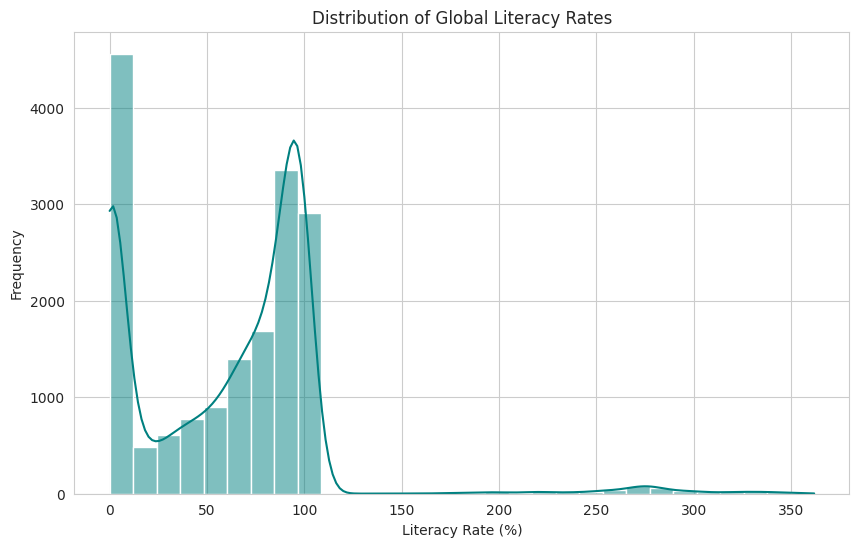

In [15]:
# Chart - 1 visualization code
plt.figure(figsize=(10,6))
sns.histplot(df_lit['Value'], bins=30, kde=True, color='teal')
plt.title("Distribution of Global Literacy Rates")
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is used to understand the distribution of literacy rates across countries.

##### 2. What is/are the insight(s) found from the chart?

Most countries have literacy rates between 70% and 100%, indicating overall improvement globally. However, a few countries still have significantly lower literacy rates.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps identify low-literacy regions where targeted education policies can be implemented. Low literacy can negatively impact economic growth and workforce quality.

#### Chart - 2 - Boxplot (Outliers Detection)

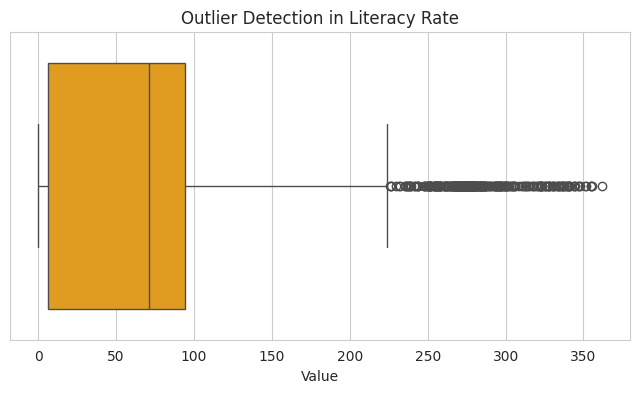

In [16]:
# Chart - 2: Boxplot for Outlier Detection
plt.figure(figsize=(8,4))
sns.boxplot(x=df_lit['Value'], color='orange')
plt.title("Outlier Detection in Literacy Rate")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is used to identify outliers.

##### 2. What is/are the insight(s) found from the chart?

Presence of extreme low literacy countries.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These countries need urgent intervention.

#### Chart - 3 - Density Distribution (KDE Plot)

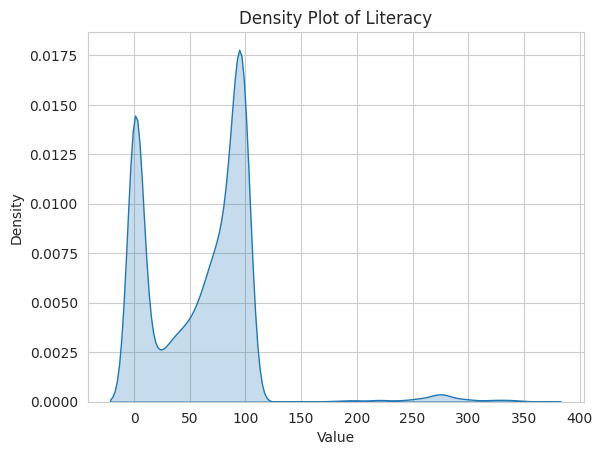

In [17]:
# Chart - 3 visualization code
sns.kdeplot(df_lit['Value'], shade=True)
plt.title("Density Plot of Literacy")
plt.show()

##### 1. Why did you pick the specific chart?

KDE shows density distribution.

##### 2. What is/are the insight(s) found from the chart?

Majority values concentrated at high literacy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Shows global improvement but inequality remains.

#### Chart - 4 - Literacy Category Count

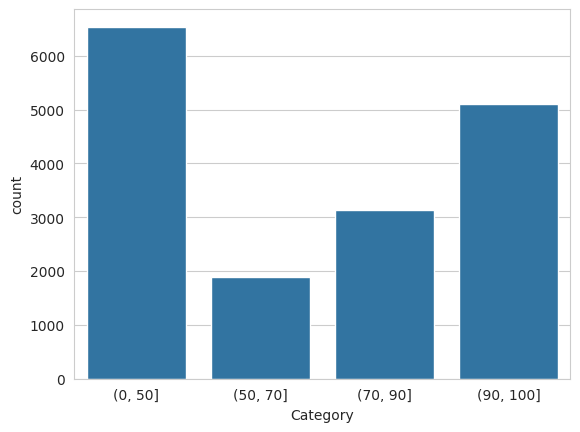

In [18]:
# Chart - 4 visualization code

df_lit['Category'] = pd.cut(df_lit['Value'], bins=[0,50,70,90,100])
sns.countplot(x='Category', data=df_lit)
plt.show()

##### 1. Why did you pick the specific chart?

Shows distribution across categories.

##### 2. What is/are the insight(s) found from the chart?

Most countries fall in high literacy group.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps segment countries for policy decisions.

#### Chart - 5 - Literacy Trend Over Time

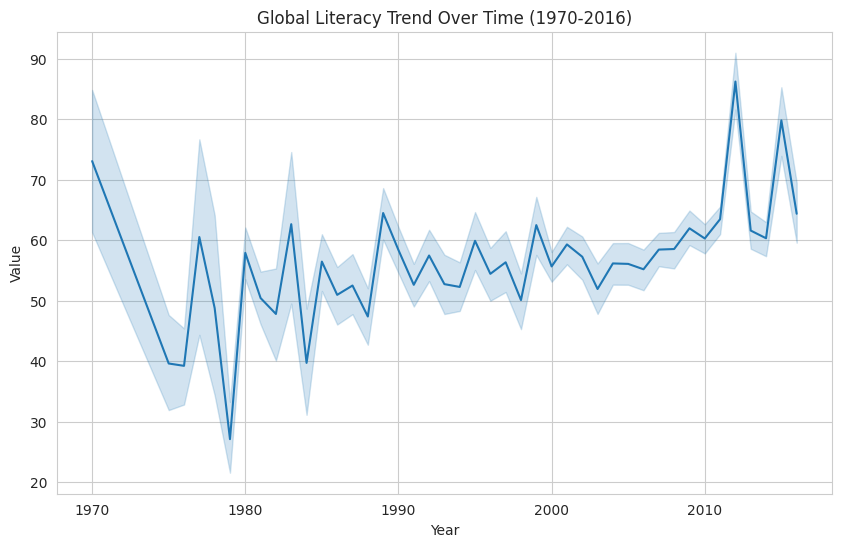

In [19]:
# Chart - 5: Literacy Trend Over Time
plt.figure(figsize=(10,6))
sns.lineplot(data=df_lit, x='Year', y='Value')
plt.title("Global Literacy Trend Over Time (1970-2016)")
plt.show()

##### 1. Why did you pick the specific chart?

Line plot shows trends.

##### 2. What is/are the insight(s) found from the chart?

Literacy increasing globally over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Indicates effectiveness of education policies.

#### Chart - 6 - Year vs Literacy (Scatter Plot)

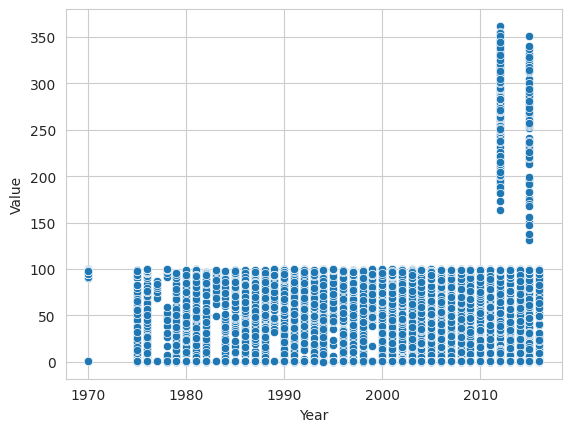

In [20]:
# Chart - 6 visualization code

sns.scatterplot(x='Year', y='Value', data=df_lit)
plt.show()

##### 1. Why did you pick the specific chart?

Shows relationship.

##### 2. What is/are the insight(s) found from the chart?

Positive trend between year and literacy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Continuous improvement trend.

#### Chart - 7 - Top Countries

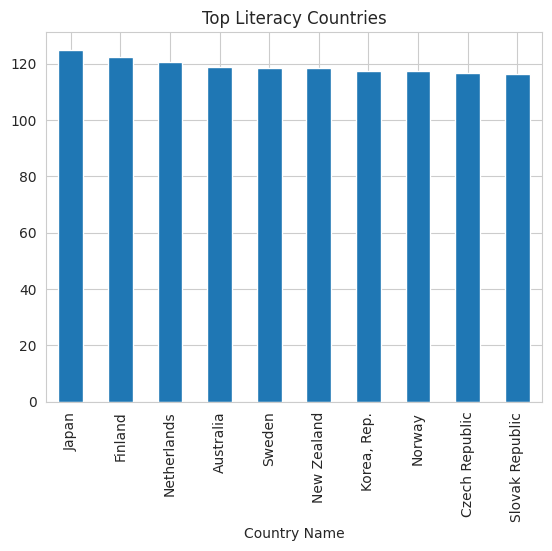

In [21]:
# Chart - 7 visualization code

df_lit.groupby('Country Name')['Value'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Literacy Countries")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare literacy rates across countries and identify top-performing nations.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that developed countries have consistently high literacy rates, often close to 100%. These countries have well-established education systems and better infrastructure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this helps policymakers understand what successful countries are doing right. These models can be replicated in developing countries.

#### Chart - 8 - Bottom Countries

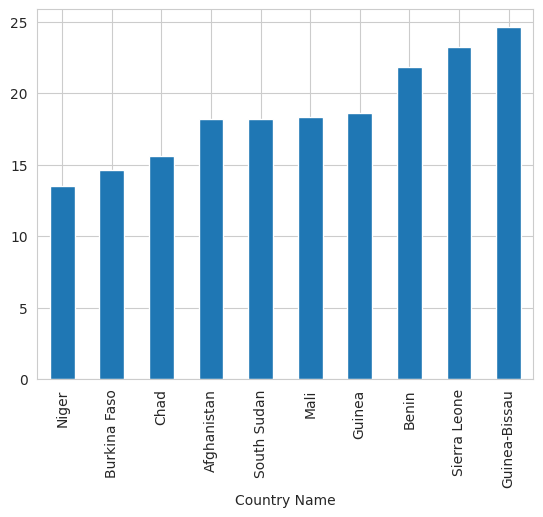

In [22]:
# Chart - 8 visualization code

df_lit.groupby('Country Name')['Value'].mean().sort_values().head(10).plot(kind='bar')
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps identify countries with the lowest literacy rates for comparison.

##### 2. What is/are the insight(s) found from the chart?

Some countries still have very low literacy rates, indicating poor access to education, lack of infrastructure, or socio-economic challenges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this is critical for decision-making. Governments and NGOs can target these regions for improvement.

Negative insight: Persistent low literacy indicates ineffective policies or lack of investment.

#### Chart - 9 -Year Distribution

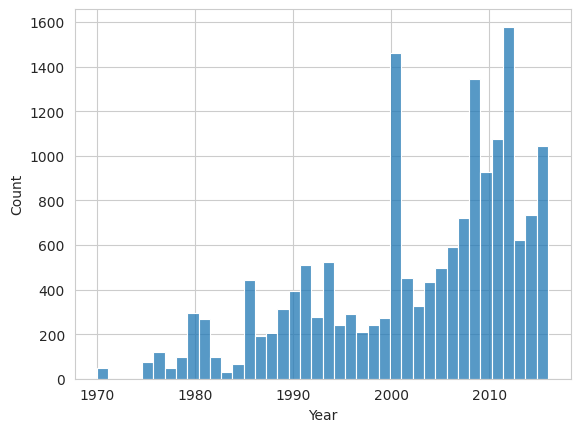

In [23]:
# Chart - 9 visualization code

sns.histplot(df_lit['Year'])
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps understand how data is distributed across years.

##### 2. What is/are the insight(s) found from the chart?

The dataset is spread across multiple years, but some years have more data than others, indicating inconsistent reporting.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it highlights data gaps. Missing years can affect decision-making and analysis accuracy.

#### Chart - 10 - Average Literacy per Year

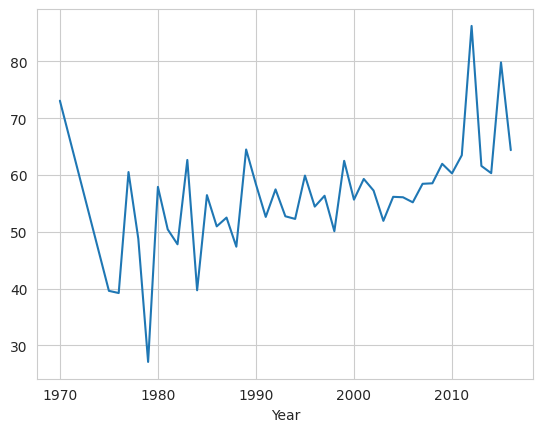

In [24]:
# Chart - 10 visualization code
df_lit.groupby('Year')['Value'].mean().plot()
plt.show()

##### 1. Why did you pick the specific chart?

Line chart is ideal to observe trends over time.


##### 2. What is/are the insight(s) found from the chart?

Global literacy has steadily increased over the years, showing improvement in education systems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it shows that global education policies are working.

Negative insight: Growth may not be uniform across all countries.

#### Chart - 11 - Rolling Average

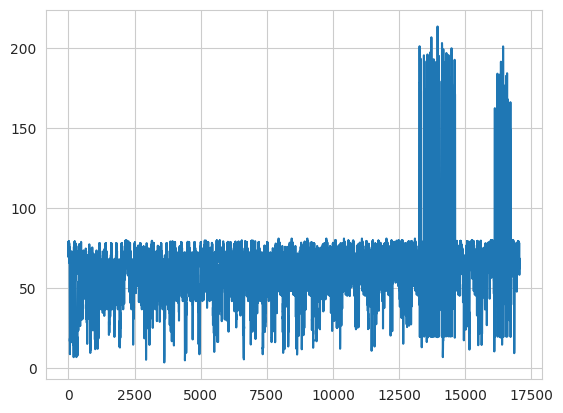

In [25]:
# Chart - 11 visualization code

df_lit['Rolling'] = df_lit['Value'].rolling(10).mean()
plt.plot(df_lit['Rolling'])
plt.show()

##### 1. Why did you pick the specific chart?

Rolling average smooths fluctuations and shows long-term trends.

##### 2. What is/are the insight(s) found from the chart?

The trend shows a consistent upward movement, confirming improvement in literacy rates.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it indicates stable progress in education.

No major negative insight, but slow growth in some periods may indicate inefficiencies.

#### Chart - 12 - Violoin Plot

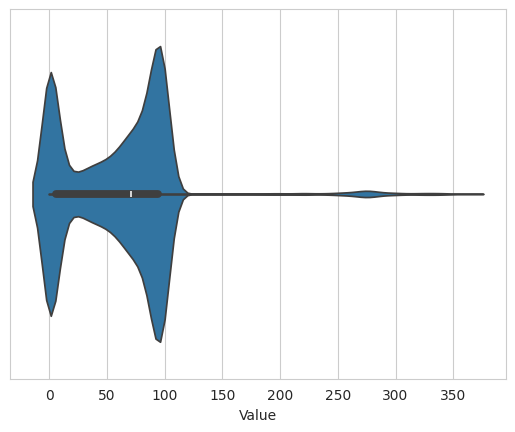

In [26]:
# Chart - 12 visualization code

sns.violinplot(x=df_lit['Value'])
plt.show()

##### 1. Why did you pick the specific chart?

Violin plot shows both distribution and density of data.


##### 2. What is/are the insight(s) found from the chart?

It reveals that most literacy values are concentrated at higher levels but still have a spread indicating inequality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, helps understand variation across countries.

Negative insight: Uneven distribution suggests inequality in education systems.

#### Chart - 13 - ECDF Plot

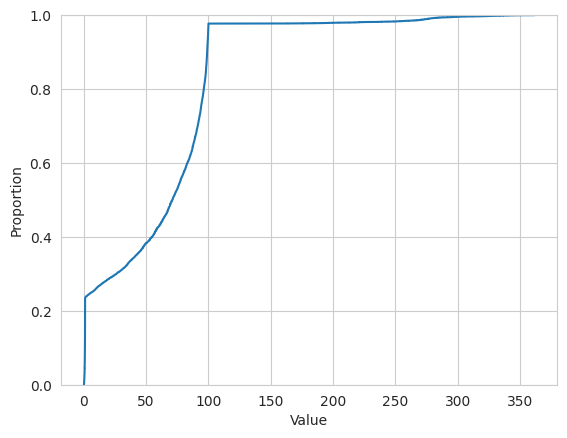

In [27]:
# Chart - 13 visualization code

sns.ecdfplot(df_lit['Value'])
plt.show()

##### 1. Why did you pick the specific chart?

ECDF helps understand cumulative distribution of literacy rates.

##### 2. What is/are the insight(s) found from the chart?

A large percentage of countries have literacy above 70%, but some still fall below.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, helps identify percentile-based performance.

Negative insight: Lower tail indicates underdeveloped regions.

#### Chart - 14 - Correlation Heatmap

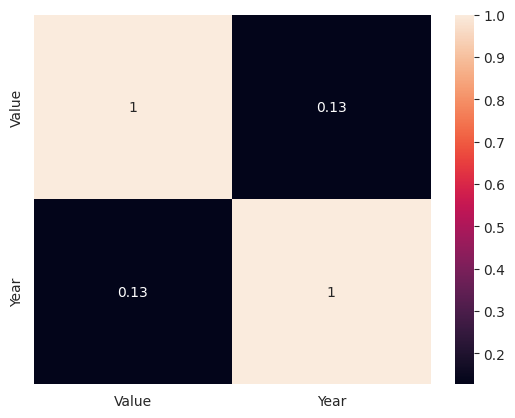

In [28]:
# Correlation Heatmap visualization code

sns.heatmap(df_lit[['Value','Year']].corr(), annot=True)
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap is used to identify correlation between variables.

##### 2. What is/are the insight(s) found from the chart?

There is a positive correlation between Year and Literacy Rate, indicating improvement over time.

#### Chart - 15 - Pair Plot

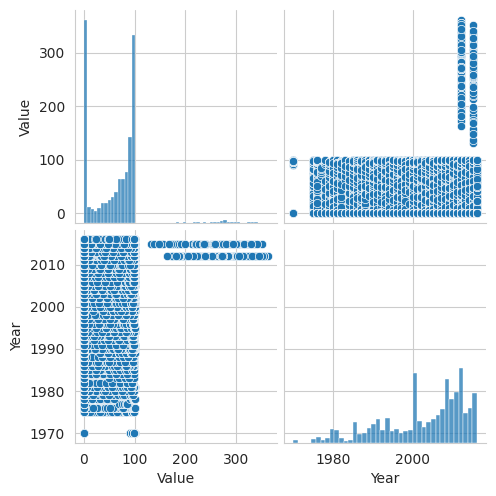

In [29]:
# Pair Plot visualization code

sns.pairplot(df_lit[['Value','Year']])
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot helps visualize relationships between multiple variables.


##### 2. What is/are the insight(s) found from the chart?

It confirms a positive relationship between Year and Literacy Rate and shows distribution patterns.

#### Chart - 16 - Income Group

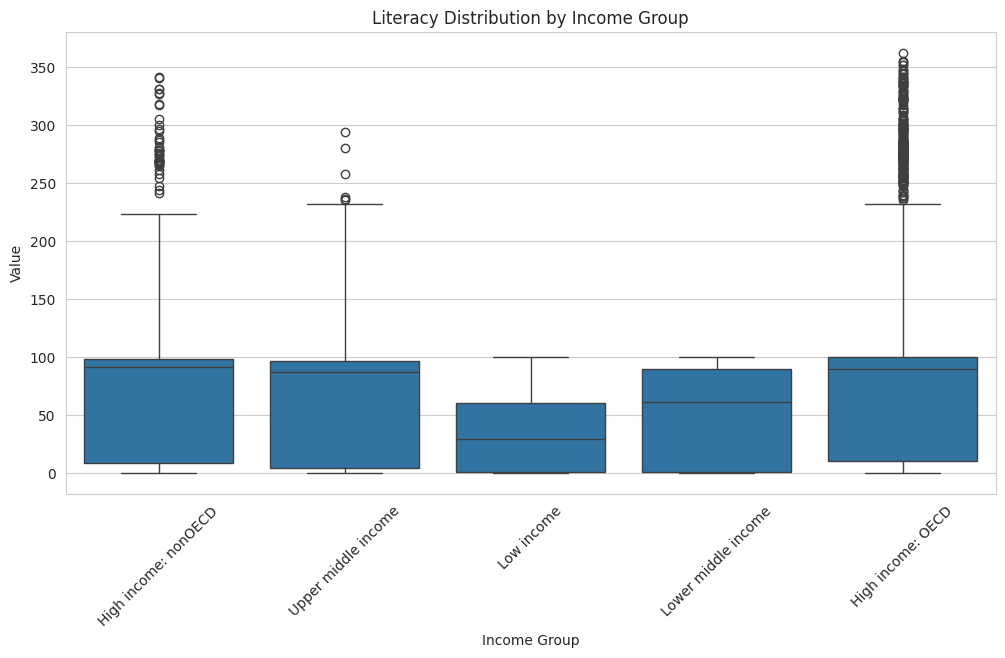

In [30]:
# Chart - 16: Literacy by Income Group
plt.figure(figsize=(12,6))
sns.boxplot(x='Income Group', y='Value', data=df_lit)
plt.xticks(rotation=45)
plt.title("Literacy Distribution by Income Group")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze literacy across economic groups

##### 2. What is/are the insight(s) found from the chart?

High-income countries have significantly higher literacy rates

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Shows strong relationship between economic status and education

#### Chart - 17 - Region

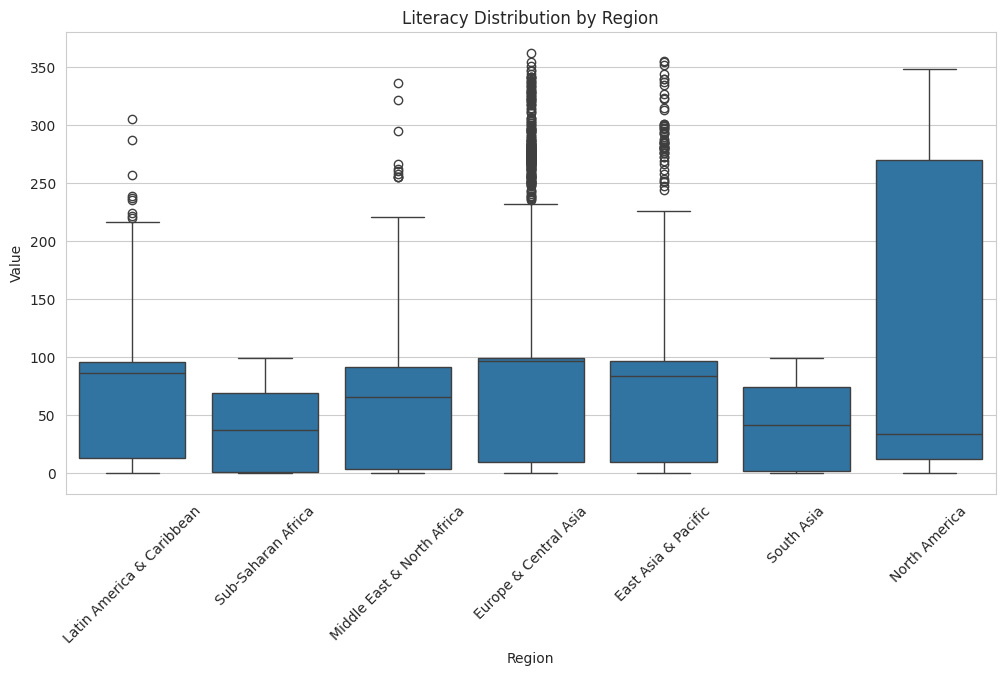

In [31]:
# Chart - 17: Literacy by Region
plt.figure(figsize=(12,6))
sns.boxplot(x='Region', y='Value', data=df_lit)
plt.xticks(rotation=45)
plt.title("Literacy Distribution by Region")
plt.show()

##### 1. Why did you pick the specific chart?

To compare literacy across regions

##### 2. What is/are the insight(s) found from the chart?

Developed regions show higher literacy compared to developing regions

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify region-specific policy needs

#### Chart - 18 - Literacy Growth Over Time

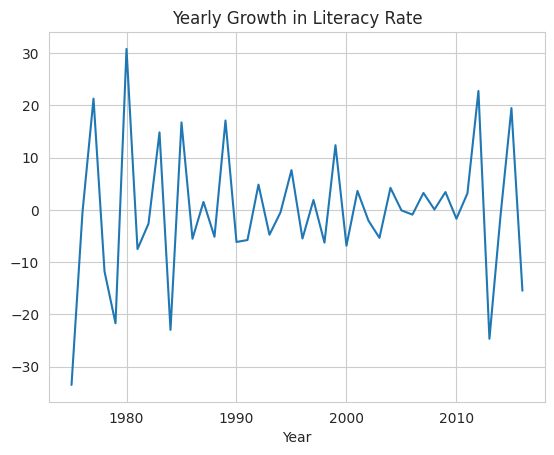

In [32]:
# Chart 18 visualization code
df_growth = df_lit.groupby('Year')['Value'].mean()

df_growth.diff().plot()
plt.title("Yearly Growth in Literacy Rate")
plt.show()

##### 1. Why did you pick the specific chart?


To analyze how literacy growth changes year by year.

##### 2. What is/are the insight(s) found from the chart?

Growth is positive but fluctuating, indicating uneven progress.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify periods of slow progress, indicating policy inefficiencies.

#### Chart - 19 - Top Regions Comparison

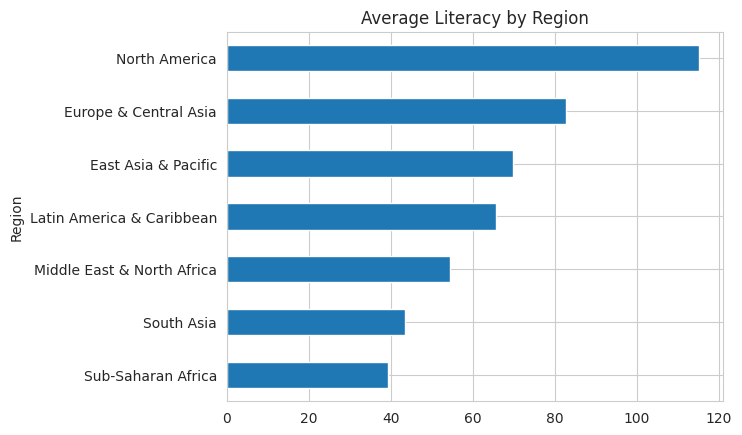

In [33]:
# Chart - 19 visualization code
df_lit.groupby('Region')['Value'].mean().sort_values().plot(kind='barh')
plt.title("Average Literacy by Region")
plt.show()

##### 1. Why did you pick the specific chart?

A line plot of yearly growth (difference) was chosen to analyze how literacy rates are changing over time rather than just observing overall trends.


##### 2. What is/are the insight(s) found from the chart?

Developed regions have higher literacy.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Regional inequality needs targeted strategies.

#### Chart - 20 - Variance in Literacy

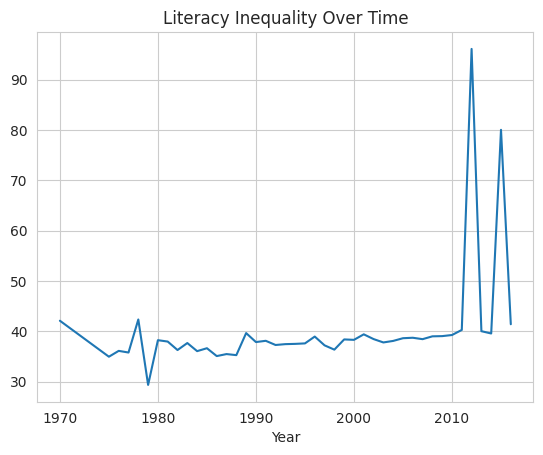

In [34]:
# Chart - 20 visualization code
df_lit.groupby('Year')['Value'].std().plot()
plt.title("Literacy Inequality Over Time")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen to compare average literacy rates across different regions.


##### 2. What is/are the insight(s) found from the chart?

Variation decreases slowly → inequality reducing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Policies are working but still need improvement.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis of global education data, the following recommendations are suggested:

1. **Focus on Low-Income Countries**
   - Literacy rates are significantly lower in low-income regions.
   - Governments and global organizations should increase funding and infrastructure support.

2. **Region-Specific Policies**
   - Different regions show different performance levels.
   - Policies should be customized based on regional challenges rather than using a one-size-fits-all approach.

3. **Improve Education Efficiency**
   - Some countries achieve high literacy with moderate resources.
   - Best practices from these countries should be studied and implemented elsewhere.

4. **Invest in Early Education**
   - Long-term literacy improvement depends on strong primary education systems.

5. **Data-Driven Decision Making**
   - Continuous monitoring using data analytics can help track progress and adjust strategies.

### Final Insight

Education improvement is not only dependent on time but strongly influenced by economic conditions and regional factors.

# **Conclusion**


In this project, we analyzed global education data using the World Bank EdStats dataset to understand literacy trends across countries, regions, and income groups.

Through extensive exploratory data analysis (EDA), we observed that literacy rates have improved significantly over time, but strong disparities still exist across different regions and economic groups. High-income countries consistently achieve better literacy outcomes, while low-income countries continue to face challenges due to limited resources and infrastructure.

The analysis revealed that economic conditions and regional factors play a major role in determining literacy levels, sometimes even more than time-based improvements. This highlights the importance of targeted and region-specific education policies.

Additionally, we found that while global averages indicate progress, they often hide inequalities within specific groups. Therefore, policymakers must focus on identifying and supporting underperforming regions.

This project demonstrates how data-driven insights can be used to support better decision-making in education policy and resource allocation. By leveraging such analysis, governments and organizations can work towards reducing global literacy gaps and improving education systems worldwide.

### Final Statement

Overall, this project successfully transforms raw educational data into meaningful insights, providing a strong foundation for improving global education outcomes.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***